In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [43]:
data = pd.read_csv('GlobalTemperatures.csv', parse_dates=['dt'])
print("Dimensions of the dataset:", data.shape)
print(data.columns)
data.head()

Dimensions of the dataset: (3192, 9)
Index(['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty',
       'LandMaxTemperature', 'LandMaxTemperatureUncertainty',
       'LandMinTemperature', 'LandMinTemperatureUncertainty',
       'LandAndOceanAverageTemperature',
       'LandAndOceanAverageTemperatureUncertainty'],
      dtype='object')


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


# Check for missing values

In [44]:
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)
data.head()

Missing values in each column:
 dt                                              0
LandAverageTemperature                         12
LandAverageTemperatureUncertainty              12
LandMaxTemperature                           1200
LandMaxTemperatureUncertainty                1200
LandMinTemperature                           1200
LandMinTemperatureUncertainty                1200
LandAndOceanAverageTemperature               1200
LandAndOceanAverageTemperatureUncertainty    1200
dtype: int64


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


# Check for duplicates

In [45]:
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


# Check for outliers using the describe method

In [46]:
description = data.describe()
print("Statistical summary of the dataset:\n", description)
# Handle missing values by imputing with the mean for numeric columns
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].mean())
data.head()

Statistical summary of the dataset:
                                   dt  LandAverageTemperature  \
count                           3192             3180.000000   
mean   1882-12-15 23:02:15.338345984                8.374731   
min              1750-01-01 00:00:00               -2.080000   
25%              1816-06-23 12:00:00                4.312000   
50%              1882-12-16 12:00:00                8.610500   
75%              1949-06-08 12:00:00               12.548250   
max              2015-12-01 00:00:00               19.021000   
std                              NaN                4.381310   

       LandAverageTemperatureUncertainty  LandMaxTemperature  \
count                        3180.000000         1992.000000   
mean                            0.938468           14.350601   
min                             0.034000            5.900000   
25%                             0.186750           10.212000   
50%                             0.392000           14.760000   
75

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,14.350601,0.479782,2.743595,0.431849,15.212566,0.128532
1,1750-02-01,3.083,3.702,14.350601,0.479782,2.743595,0.431849,15.212566,0.128532
2,1750-03-01,5.626,3.076,14.350601,0.479782,2.743595,0.431849,15.212566,0.128532
3,1750-04-01,8.490,2.451,14.350601,0.479782,2.743595,0.431849,15.212566,0.128532
4,1750-05-01,11.573,2.072,14.350601,0.479782,2.743595,0.431849,15.212566,0.128532


# Check for missing values

In [47]:
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)
# Normalize numeric features
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
data[numeric_columns] = (data[numeric_columns] - data[numeric_columns].mean()) / data[numeric_columns].std()
data.head()

Missing values in each column:
 dt                                           0
LandAverageTemperature                       0
LandAverageTemperatureUncertainty            0
LandMaxTemperature                           0
LandMaxTemperatureUncertainty                0
LandMinTemperature                           0
LandMinTemperatureUncertainty                0
LandAndOceanAverageTemperature               0
LandAndOceanAverageTemperatureUncertainty    0
dtype: int64


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,-1.221279,2.408250,-1.043646e-15,0.0,0.0,0.0,0.0,0.0
1,1750-02-01,-1.210074,2.525212,-1.043646e-15,0.0,0.0,0.0,0.0,0.0
2,1750-03-01,-0.628560,1.953197,-1.043646e-15,0.0,0.0,0.0,0.0,0.0
3,1750-04-01,0.026359,1.382095,-1.043646e-15,0.0,0.0,0.0,0.0,0.0
4,1750-05-01,0.731357,1.035779,-1.043646e-15,0.0,0.0,0.0,0.0,0.0


In [48]:
print("Column names of the dataset:", data.columns)
data.head()

Column names of the dataset: Index(['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty',
       'LandMaxTemperature', 'LandMaxTemperatureUncertainty',
       'LandMinTemperature', 'LandMinTemperatureUncertainty',
       'LandAndOceanAverageTemperature',
       'LandAndOceanAverageTemperatureUncertainty'],
      dtype='object')


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,-1.221279,2.408250,-1.043646e-15,0.0,0.0,0.0,0.0,0.0
1,1750-02-01,-1.210074,2.525212,-1.043646e-15,0.0,0.0,0.0,0.0,0.0
2,1750-03-01,-0.628560,1.953197,-1.043646e-15,0.0,0.0,0.0,0.0,0.0
3,1750-04-01,0.026359,1.382095,-1.043646e-15,0.0,0.0,0.0,0.0,0.0
4,1750-05-01,0.731357,1.035779,-1.043646e-15,0.0,0.0,0.0,0.0,0.0


# Line plot using Seaborn

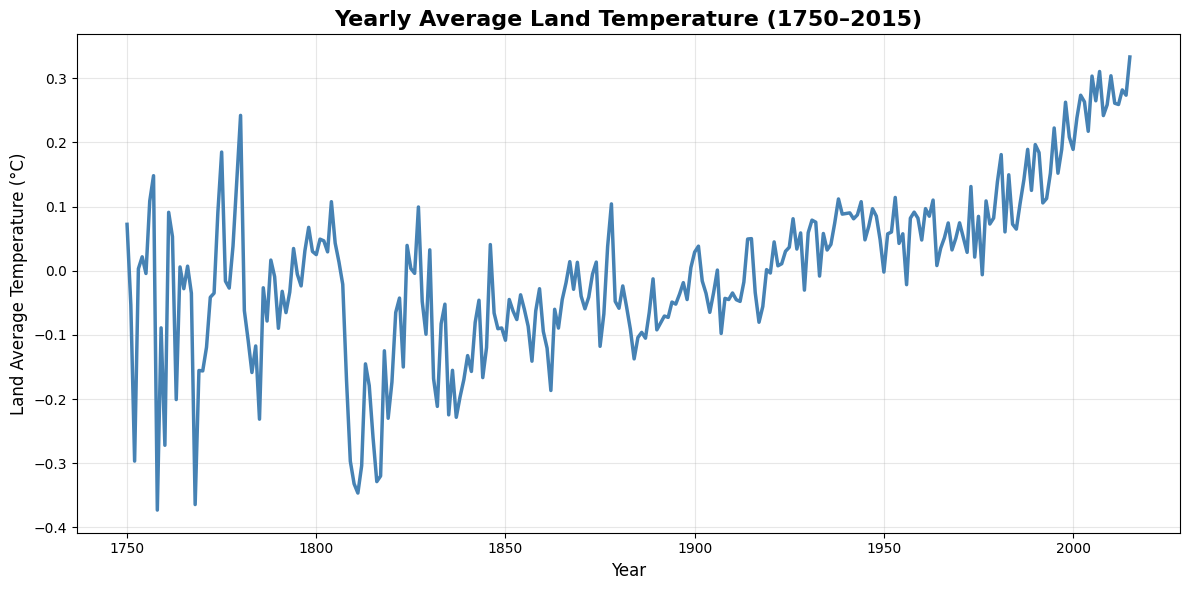

In [49]:
# Create yearly average
yearly_temp = (
    data.groupby(data['dt'].dt.year)['LandAverageTemperature']
    .mean()
    .reset_index()
)

yearly_temp.columns = ['Year', 'LandAverageTemperature']

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_temp,
    x='Year',
    y='LandAverageTemperature',
    linewidth=2.5,
    color='steelblue'
)

plt.title('Yearly Average Land Temperature (1750–2015)',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Land Average Temperature (°C)', fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plot using Matplotlib

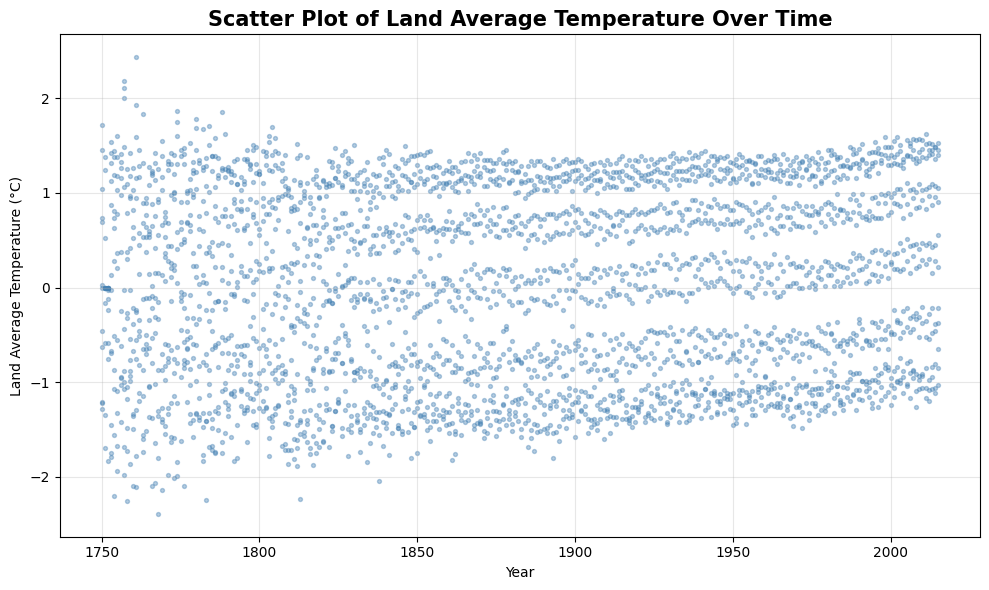

In [50]:
plt.figure(figsize=(10,6))
plt.scatter(
    data['dt'].dt.year,
    data['LandAverageTemperature'],
    s=8,
    alpha=0.4,
    color='steelblue'
)
plt.title('Scatter Plot of Land Average Temperature Over Time',
          fontsize=15, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Land Average Temperature (°C)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Histogram using Seaborn

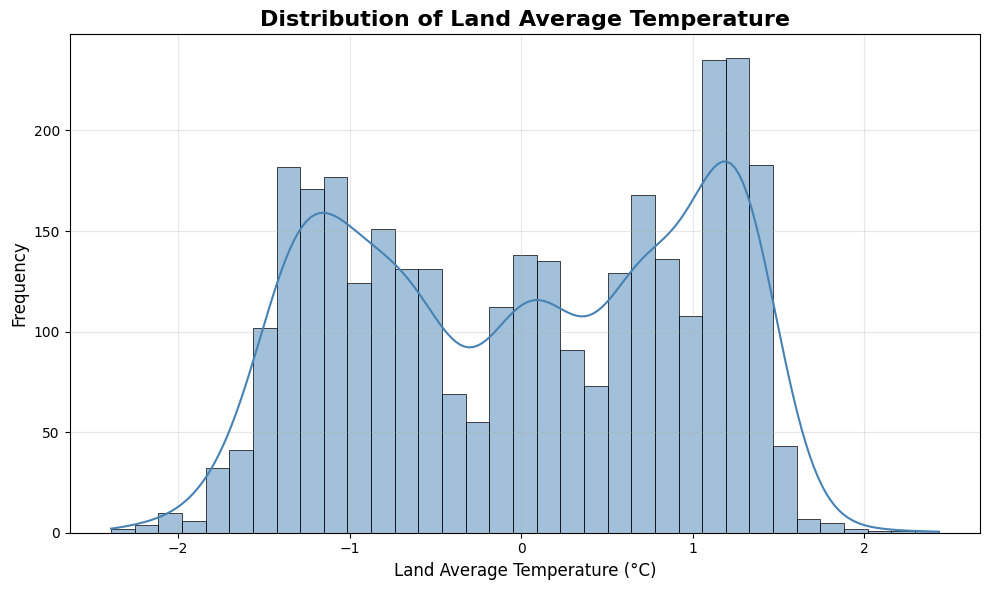

In [51]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data['LandAverageTemperature'].dropna(),
    bins=35,
    kde=True,
    color='steelblue',
    edgecolor='black',
    linewidth=0.5
)
plt.title('Distribution of Land Average Temperature', fontsize=16, fontweight='bold')
plt.xlabel('Land Average Temperature (°C)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

# Create the bar chart

In [52]:
fig = px.bar(data, x=data['dt'].dt.year, y='LandAverageTemperature', 
             title='Bar Chart of Land Average Temperature Over Time (Scaled)')

# Customize bars

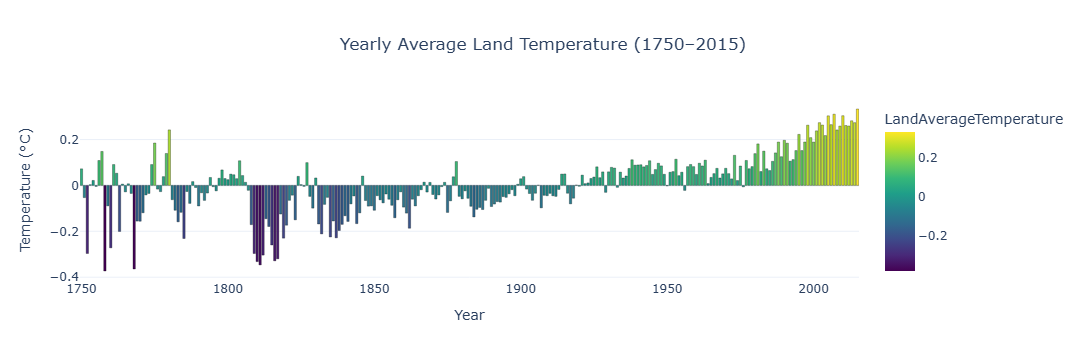

In [53]:
# Create yearly average
yearly_temp = (
    data.groupby(data['dt'].dt.year)['LandAverageTemperature']
    .mean()
    .reset_index()
)

yearly_temp.columns = ['Year', 'LandAverageTemperature']

# Create bar chart
fig = px.bar(
    yearly_temp,
    x='Year',
    y='LandAverageTemperature',
    title='Yearly Average Land Temperature (1750–2015)',
    color='LandAverageTemperature',
    color_continuous_scale='Viridis'
)

fig.update_traces(
    marker_line_color='black',
    marker_line_width=0.3
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    xaxis_title='Year',
    yaxis_title='Temperature (°C)'
)

fig.show()

# Adjust y-axis range

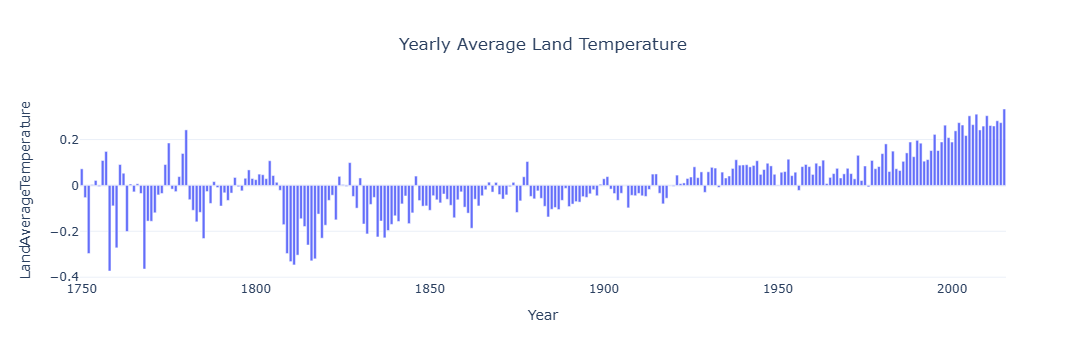

In [54]:
yearly_temp = (
    data.groupby(data['dt'].dt.year)['LandAverageTemperature']
    .mean()
    .reset_index()
)

yearly_temp.columns = ['Year', 'LandAverageTemperature']

fig = px.bar(
    yearly_temp,
    x='Year',
    y='LandAverageTemperature',
    title='Yearly Average Land Temperature'
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5
)

fig.show()

# Heatmap using Seaborn

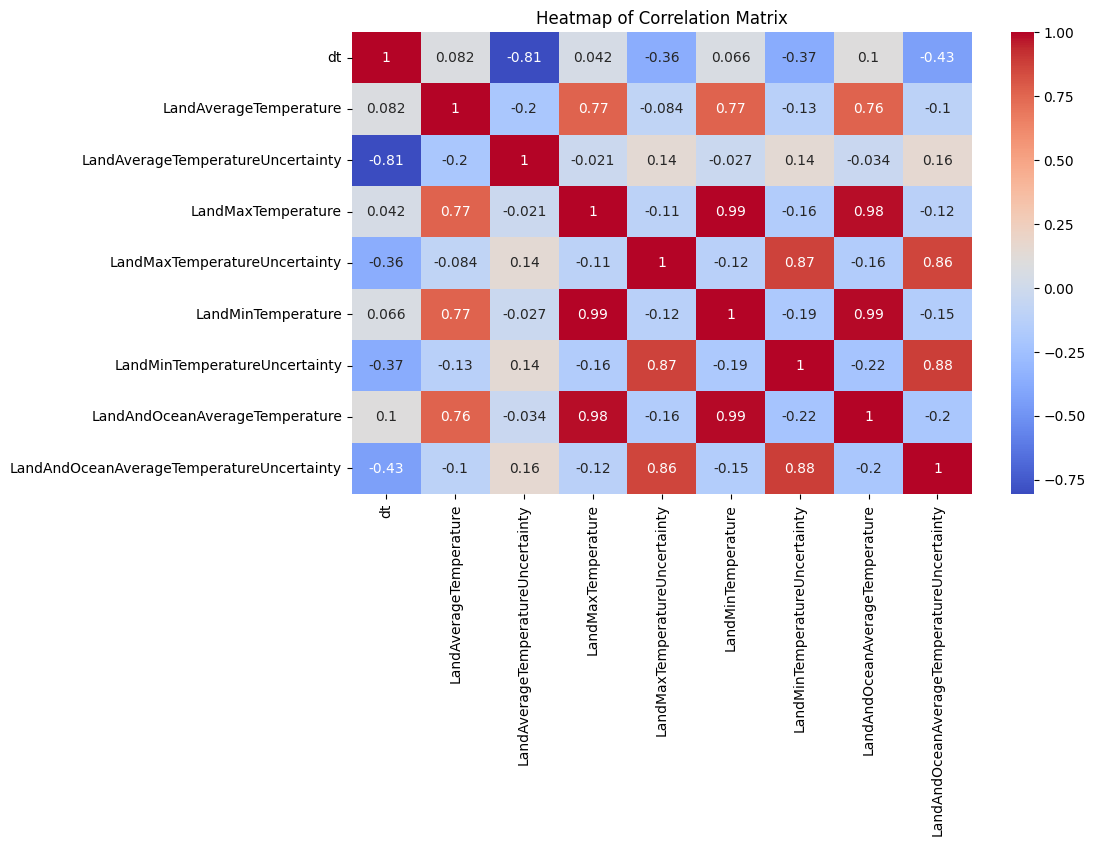

In [55]:
plt.figure(figsize=(10, 6))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Heatmap of Correlation Matrix')
plt.show()

# Area chart using Plotly

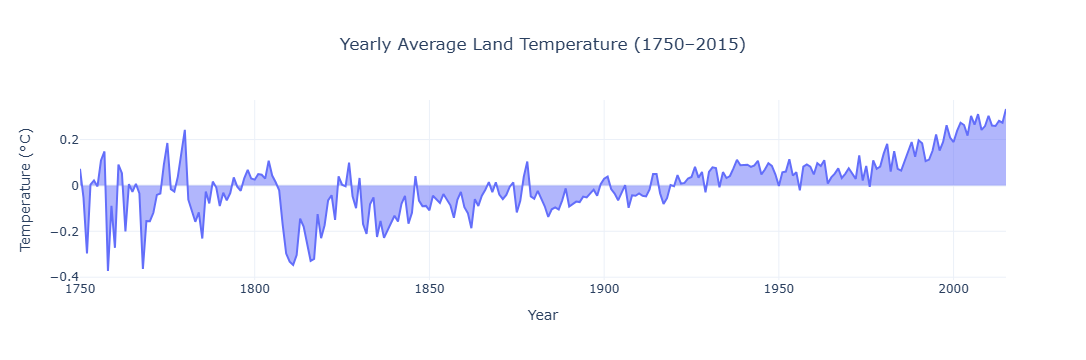

In [56]:
# Yearly average temperature
yearly_temp = (
    data.groupby(data['dt'].dt.year)['LandAverageTemperature']
        .mean()
        .reset_index()
)

yearly_temp.columns = ['Year', 'LandAverageTemperature']

fig = px.area(
    yearly_temp,
    x='Year',
    y='LandAverageTemperature',
    title='Yearly Average Land Temperature (1750–2015)',
    labels={
        'Year': 'Year',
        'LandAverageTemperature': 'Temperature (°C)'
    }
)

fig.update_traces(line=dict(width=2))
fig.update_layout(
    template='plotly_white',
    title_x=0.5
)

fig.show()

# Advanced Plot 1: Subplots using Matplotlib

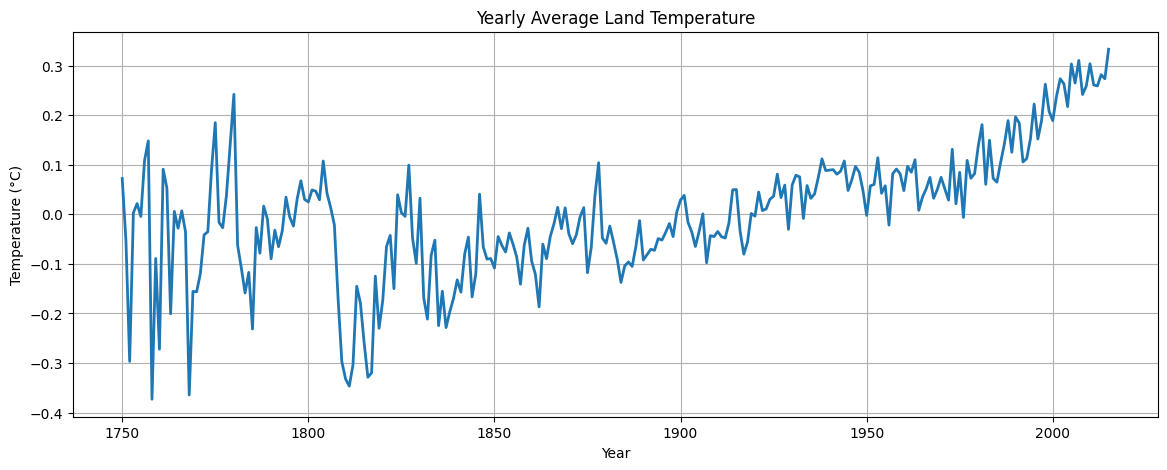

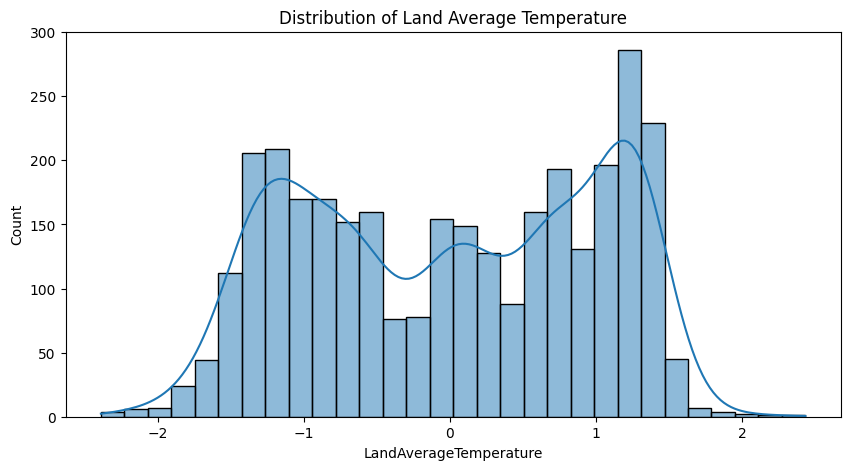

In [57]:
data['dt'] = pd.to_datetime(data['dt'])

yearly_avg = (
    data.groupby(data['dt'].dt.year)['LandAverageTemperature']
        .mean()
        .reset_index()
)

yearly_avg.columns = ['Year', 'LandAverageTemperature']

plt.figure(figsize=(14,5))
plt.plot(yearly_avg['Year'], yearly_avg['LandAverageTemperature'], linewidth=2)
plt.title("Yearly Average Land Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(data['LandAverageTemperature'].dropna(), bins=30, kde=True)
plt.title("Distribution of Land Average Temperature")
plt.show()

In [58]:
df_country = pd.read_csv("GlobalLandTemperaturesByCountry.csv")

In [59]:
df_country.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [60]:
df_country.isnull().sum()

dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
dtype: int64

In [61]:
import warnings 
warnings.filterwarnings('ignore')

In [62]:
df_country['AverageTemperature'].fillna(df_country['AverageTemperature'].mean(),inplace=True)

In [63]:
df_country['AverageTemperatureUncertainty'].fillna(df_country['AverageTemperatureUncertainty'].mean(),inplace=True)

In [64]:
df_country.isnull().sum()

dt                               0
AverageTemperature               0
AverageTemperatureUncertainty    0
Country                          0
dtype: int64

# Advanced Plot 2: Choropleth Map using Plotly

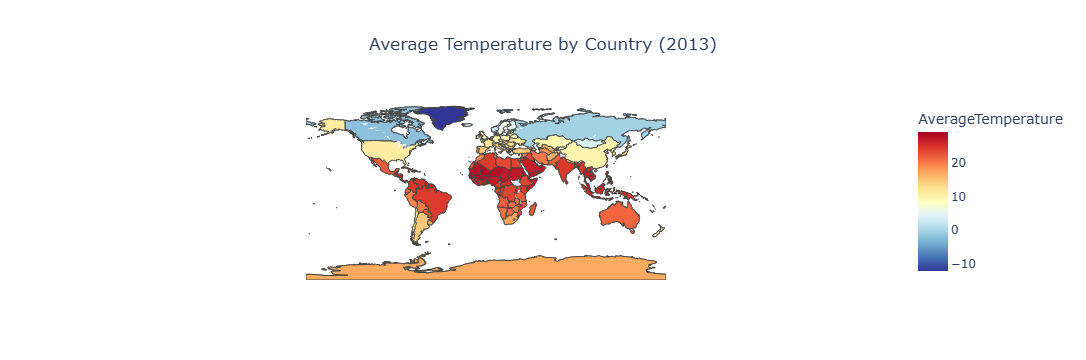

In [65]:
import plotly.express as px

# Convert date column to datetime
df_country['dt'] = pd.to_datetime(df_country['dt'])

# Use the latest available year
latest_year = df_country['dt'].dt.year.max()

map_data = (
    df_country[df_country['dt'].dt.year == latest_year]
    .groupby('Country', as_index=False)['AverageTemperature']
    .mean()
)

# Choropleth Map
fig = px.choropleth(
    map_data,
    locations='Country',
    locationmode='country names',
    color='AverageTemperature',
    hover_name='Country',
    color_continuous_scale='RdYlBu_r',
    title=f'Average Temperature by Country ({latest_year})'
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    title_x=0.5
)

fig.show()


In [66]:
df_state = pd.read_csv("GlobalLandTemperaturesByState.csv")

In [67]:
df_state.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,State,Country
0,1855-05-01,25.544,1.171,Acre,Brazil
1,1855-06-01,24.228,1.103,Acre,Brazil
2,1855-07-01,24.371,1.044,Acre,Brazil
3,1855-08-01,25.427,1.073,Acre,Brazil
4,1855-09-01,25.675,1.014,Acre,Brazil


In [68]:
df_state.isnull().sum()

dt                                   0
AverageTemperature               25648
AverageTemperatureUncertainty    25648
State                                0
Country                              0
dtype: int64

In [69]:
import warnings 
warnings.filterwarnings('ignore')

In [70]:
df_state['AverageTemperature'].fillna(df_country['AverageTemperature'].mean(),inplace=True)

In [71]:
df_state['AverageTemperatureUncertainty'].fillna(df_country['AverageTemperatureUncertainty'].mean(),inplace=True)

In [72]:
df_state.isnull().sum()

dt                               0
AverageTemperature               0
AverageTemperatureUncertainty    0
State                            0
Country                          0
dtype: int64

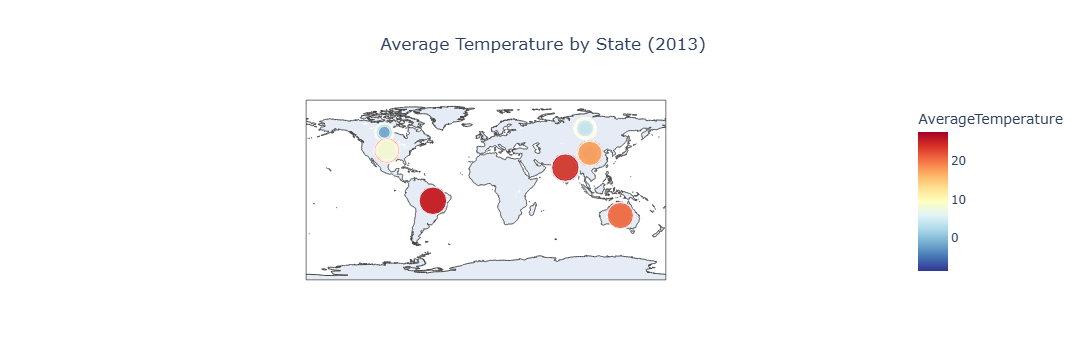

In [73]:
import pandas as pd
import plotly.express as px

# Convert date column to datetime
df_state['dt'] = pd.to_datetime(df_state['dt'])

# Use latest available year
latest_year = df_state['dt'].dt.year.max()

map_data = (
    df_state[df_state['dt'].dt.year == latest_year]
    .groupby(['State', 'Country'], as_index=False)['AverageTemperature']
    .mean()
    .dropna()
)

# Remove negative values for marker size
map_data['Temp_Size'] = map_data['AverageTemperature'] - map_data['AverageTemperature'].min() + 1

fig = px.scatter_geo(
    map_data,
    locations='Country',
    locationmode='country names',
    hover_name='State',
    hover_data=['Country', 'AverageTemperature'],
    size='Temp_Size',
    color='AverageTemperature',
    color_continuous_scale='RdYlBu_r',
    title=f'Average Temperature by State ({latest_year})'
)

fig.update_layout(title_x=0.5)
fig.show()

## Monthly Box Plot

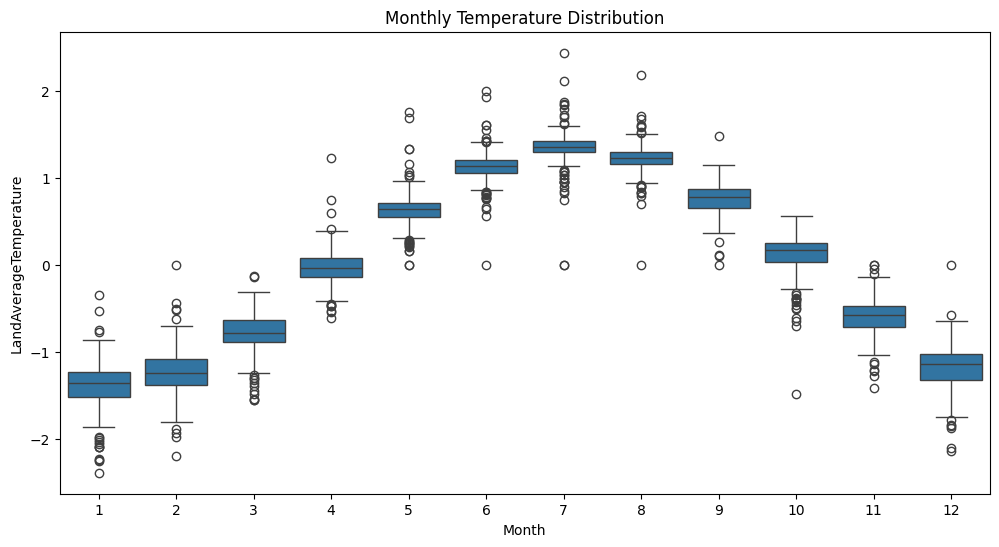

In [74]:
data['Month'] = data['dt'].dt.month

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Month',
    y='LandAverageTemperature',
    data=data
)

plt.title('Monthly Temperature Distribution')

plt.show()

# Rolling Average

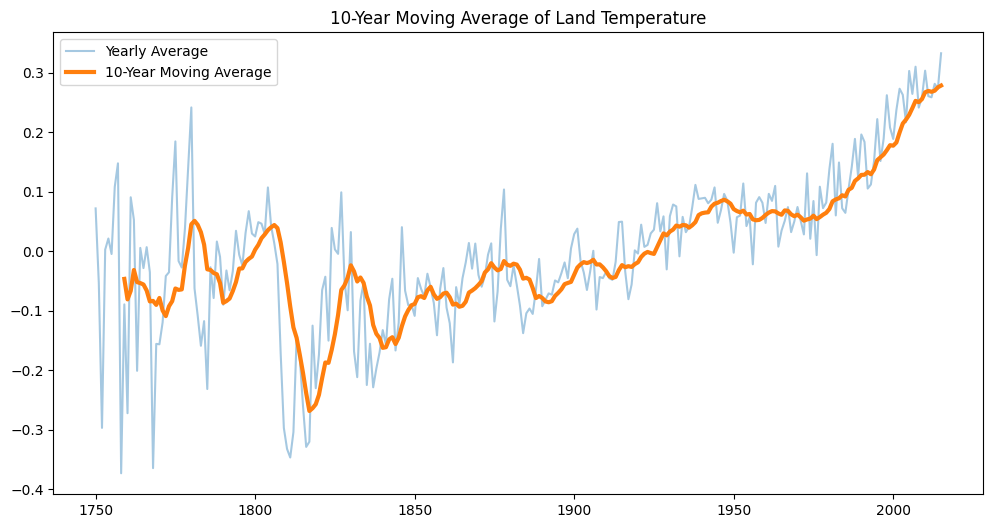

In [75]:
yearly = (
    data.groupby(data['dt'].dt.year)['LandAverageTemperature']
    .mean()
)

rolling = yearly.rolling(10).mean()

plt.figure(figsize=(12,6))

plt.plot(yearly, alpha=0.4, label='Yearly Average')
plt.plot(rolling, linewidth=3, label='10-Year Moving Average')

plt.legend()

plt.title('10-Year Moving Average of Land Temperature')

plt.show()

# Distribution Comparison

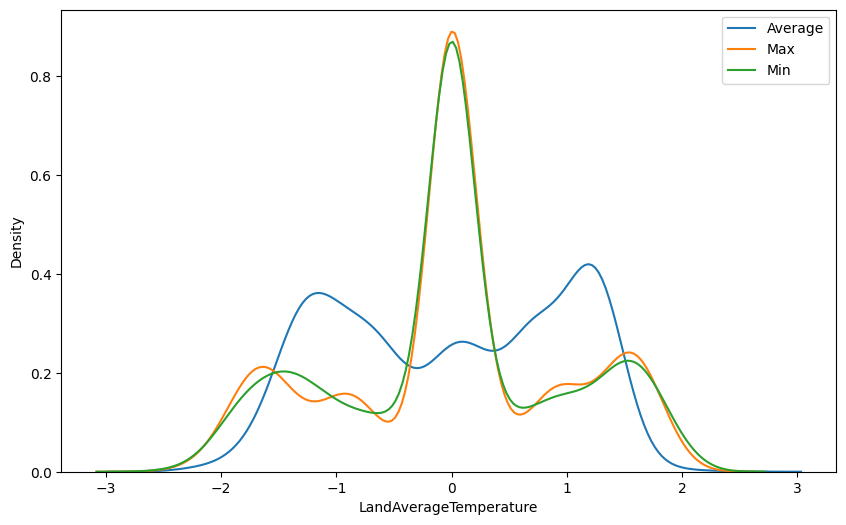

In [76]:
plt.figure(figsize=(10,6))

sns.kdeplot(data['LandAverageTemperature'], label='Average')
sns.kdeplot(data['LandMaxTemperature'], label='Max')
sns.kdeplot(data['LandMinTemperature'], label='Min')

plt.legend()

plt.show()

# Advanced Plot 3: Trend Analysis using Plotly

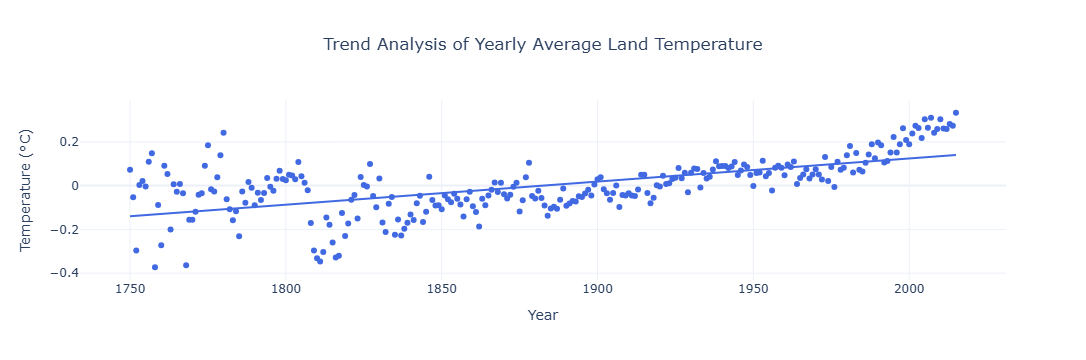

In [77]:
# Calculate yearly average
yearly_temp = (
    data.groupby(data['dt'].dt.year)['LandAverageTemperature']
    .mean()
    .reset_index()
)

yearly_temp.columns = ['Year', 'LandAverageTemperature']

fig = px.scatter(
    yearly_temp,
    x='Year',
    y='LandAverageTemperature',
    trendline='ols',
    title='Trend Analysis of Yearly Average Land Temperature',
    labels={
        'Year': 'Year',
        'LandAverageTemperature': 'Temperature (°C)'
    }
)

fig.update_traces(
    marker=dict(size=6, color='royalblue')
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5
)

fig.show()